# 🚀 Imports

In [27]:
# Maths
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# String
import urllib
import tldextract
import re

# Misc
import sys

def print_safe(url):
    '''Prints safe, unclickable URL in VS Code.'''
    sys.stdout.write(url.replace("://", "://\x00"))  # Null byte
    
# Number of CPU cores
# !lscpu

# ❗ IMPORTANT: SAFETY GUIDELINES AGAINST LINKS ⚠️

> ***READ BEFORE RUNNING ANY CELL***
>
> **The `url` column is dangerous if click link**, be careful. Other columns from are safe.
> - ⚠️ Display `df` — Always use `display(df)` so that URL are  not clickable.
> - ⚠️ Use `print_safe` — Use `print_safe(url)` so that URL are  not clickable.
> - ⚠️ String Parsing — Safe but make sure not to accidentally click link
>   - `urlparse`— Splits URL by structure
>   - `tldextract`— Splits domain specifically
>   - `re` — Finds patterns in string
> - ❌ DNS/WHOIS lookups — use `safe_dns_lookup()` only, one person runs this
> - ❌ `requests.get(url)` — never, under any circumstance


In [28]:
url = "http://mail.paypa1-secure.evil.com/login?user=1%20x"

# urlparse
from urllib.parse import urlparse
p = urlparse(url)
p.scheme    # 'http'
p.netloc    # 'mail.paypa1-secure.evil.com'
p.path      # '/login'
p.query     # 'user=1%20x'

# tldextract
ext = tldextract.extract(url)
ext.subdomain  # 'mail.paypa1-secure'
ext.domain     # 'evil'
ext.suffix     # 'com'

# re
re.search(r'\d+\.\d+\.\d+\.\d+', url)  # IP address present?
re.findall(r'\d', url)                 # digits in URL
re.search(r'%[0-9a-fA-F]{2}', url)     # hex encoding present?

print_safe(url)

http:// mail.paypa1-secure.evil.com/login?user=1%20x

---

# 🧪  Import Data

In [29]:
# Link to CSV
file_path = "../data/dataset-phishing.csv"
df = pd.read_csv(file_path)

# Move all columns with strings to the left
foo = ['url', 'dom', 'tld', 'url_len', 'dom_len', 'tld_len']
cols = foo + [col for col in df.columns if col not in foo]
df = df.reindex(columns=cols)
df.head()

,url,dom,tld,url_len,dom_len,tld_len,is_ip,subdom_cnt,letter_cnt,digit_cnt,...,under_cnt,letter_ratio,digit_ratio,spec_ratio,is_https,slash_cnt,entropy,path_len,query_len,label
0,https://www.rmit.edu.au/,rmit.edu.au,edu.au,24,11,6,0,1,17,0,...,0,0.708333,0.0,0.291667,1,3,3.709148,1,0,0
1,http://www.latrobe.edu.au/,latrobe.edu.au,edu.au,26,14,6,0,1,19,0,...,0,0.730769,0.0,0.269231,0,3,3.738149,1,0,0
2,https://www.cqu.edu.au/,cqu.edu.au,edu.au,23,10,6,0,1,16,0,...,0,0.695652,0.0,0.304348,1,3,3.609668,1,0,0
3,http://bond.edu.au/,bond.edu.au,edu.au,19,11,6,0,0,13,0,...,0,0.684211,0.0,0.315789,0,3,3.576618,1,0,0
4,http://www.csu.edu.au/,csu.edu.au,edu.au,22,10,6,0,1,15,0,...,0,0.681818,0.0,0.318182,0,3,3.503998,1,0,0


---

# 🧹 1. Data Cleaning

## 🔍 1.1 Initial Data Inspection

It was found that `NaN` values only appear in the `tld` column which is not used in the final dataframe.

In [30]:
# General info about dataset
df.info()
# df.nunique()
# df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 116600 entries, 0 to 116599
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   url           116600 non-null  str    
 1   dom           116600 non-null  str    
 2   tld           116586 non-null  str    
 3   url_len       116600 non-null  int64  
 4   dom_len       116600 non-null  int64  
 5   tld_len       116600 non-null  int64  
 6   is_ip         116600 non-null  int64  
 7   subdom_cnt    116600 non-null  int64  
 8   letter_cnt    116600 non-null  int64  
 9   digit_cnt     116600 non-null  int64  
 10  special_cnt   116600 non-null  int64  
 11  eq_cnt        116600 non-null  int64  
 12  qm_cnt        116600 non-null  int64  
 13  amp_cnt       116600 non-null  int64  
 14  dot_cnt       116600 non-null  int64  
 15  dash_cnt      116600 non-null  int64  
 16  under_cnt     116600 non-null  int64  
 17  letter_ratio  116600 non-null  float64
 18  digit_ratio   1

In [31]:
# Create clean copy of original dataset
df_clean = df.copy()
print("Initial Data Inspection\n" + "-" * 23)

# 1. Shape of dataset
print(f"1. Original Shape: {df_clean.shape}")

# 2. NaN values
print(f"2. NaN Values: {df_clean.isnull().sum().sum()}")
print(f"    - url: {df_clean['url'].isnull().sum()}")
print(f"    - dom: {df_clean['dom'].isnull().sum()}")
print(f"    - tld: {df_clean['tld'].isnull().sum()}")
# --- More info on 'tld' values ---
# display(df_clean[df_clean.isnull().any(axis=1)])

# 3. Negative values (ignored first 3 str columns)
print(f"3. Negative Values: {(df_clean.iloc[:,3:] < 0).sum().sum()}")

# 4. Remove duplicate URLs
duplicate_urls = df_clean.duplicated(subset=['url'])
print(f"4. Duplicate URLs: {duplicate_urls.sum()}")
# --- View Duplicate URLs ---
# bar = df_clean[duplicate_urls]['url'].value_counts().to_dict()
# print(bar) # WARNING: display makes URL clicable

# 5. Verify 'label' column
legit_count = df_clean[df_clean['label'] == 0].shape[0]
phish_count = df_clean[df_clean['label'] == 1].shape[0]
total_count = legit_count + phish_count
print(f"5. Label Column (Legitimate + Phishing): {legit_count + phish_count}")
print(f"    - Legitimate: {legit_count} ({legit_count/total_count:.2%})")
print(f"    - Phishing: {phish_count} ({phish_count/total_count:.2%})")
# --- More info on `label` column ---
# display(df_clean['labbel'].value_counts())

print("-" * 23)

Initial Data Inspection
-----------------------
1. Original Shape: (116600, 26)
2. NaN Values: 14
    - url: 0
    - dom: 0
    - tld: 14
3. Negative Values: 0
4. Duplicate URLs: 1369
5. Label Column (Legitimate + Phishing): 116600
    - Legitimate: 100000 (85.76%)
    - Phishing: 16600 (14.24%)
-----------------------


## 🩹 1.2 Patch Errors in Data

Since only duplicates exist within the dataset, the following will be carried out:
1. **Deletion** of rows that have duplicate `url`.

In [32]:
# Create clean copy of original dataset
df_clean = df.copy()
print("Initial Data Inspection\n" + "-" * 23)

# 1. No patch needed

# 2. No patch needed

# 3. No patch needed

# 4. Remove duplicate URLs
print(f"Removing {duplicate_urls.sum()} duplicate URLs...")
df_clean = df_clean.drop_duplicates(subset=['url'])
duplicate_urls = df_clean.duplicated(subset=['url'])
print(f"4. Duplicate URLs: {duplicate_urls.sum()}")
# --- View Duplicate URLs ---
# bar = df_clean[duplicate_urls]['url'].value_counts().to_dict()
# print(bar) # WARNING: display makes URL clicable

# 5. Verify 'label' column
legit_count = df_clean[df_clean['label'] == 0].shape[0]
phish_count = df_clean[df_clean['label'] == 1].shape[0]
total_count = legit_count + phish_count
print(f"5. Label Column (Legitimate + Phishing): {legit_count + phish_count}")
print(f"    - Legitimate: {legit_count} ({legit_count/total_count:.2%})")
print(f"    - Phishing: {phish_count} ({phish_count/total_count:.2%})")
# --- More info on `label` column ---
# display(df_clean['label'].value_counts())

print("-" * 23)

Initial Data Inspection
-----------------------
Removing 1369 duplicate URLs...
4. Duplicate URLs: 0
5. Label Column (Legitimate + Phishing): 115231
    - Legitimate: 98641 (85.60%)
    - Phishing: 16590 (14.40%)
-----------------------


---

# 🗺️ 2. EDA

We categorise the 22 features into the following groups so that our analysis is easier.

| Group              | Features                                                                 | What to look for                                      |
|--------------------|--------------------------------------------------------------------------|-------------------------------------------------------|
| Length-based (5)       | `url_len`, `dom_len`, `tld_len`, `path_len`, `query_len`                | Phishing URLs tend to be longer                      |
| Count-based (11)       | `letter_cnt`, `digit_cnt`, `special_cnt`, `eq_cnt`, `qm_cnt`, `amp_cnt`, `dot_cnt`, `dash_cnt`, `under_cnt`, `slash_cnt`, `subdom_cnt` | Abnormal counts signal obfuscation                   |
| Ratio-based (3)       | `letter_ratio`, `digit_ratio`, `spec_ratio`                             | Ratios normalize for URL length — more stable signals |
| Structural / binary (2)| `is_ip`, `is_https`                                                     | Binary — use value counts + label split              |
| Entropy (1)            | `entropy`                                                               | High entropy = random-looking, a strong phishing signal  |

In [33]:
# Remove columns with strings for numerical analysis
df_filter = df_clean.copy()
df_filter = df_filter.iloc[:,3:]
df_filter.head()

,url_len,dom_len,tld_len,is_ip,subdom_cnt,letter_cnt,digit_cnt,special_cnt,eq_cnt,qm_cnt,...,under_cnt,letter_ratio,digit_ratio,spec_ratio,is_https,slash_cnt,entropy,path_len,query_len,label
0,24,11,6,0,1,17,0,7,0,0,...,0,0.708333,0.0,0.291667,1,3,3.709148,1,0,0
1,26,14,6,0,1,19,0,7,0,0,...,0,0.730769,0.0,0.269231,0,3,3.738149,1,0,0
2,23,10,6,0,1,16,0,7,0,0,...,0,0.695652,0.0,0.304348,1,3,3.609668,1,0,0
3,19,11,6,0,0,13,0,6,0,0,...,0,0.684211,0.0,0.315789,0,3,3.576618,1,0,0
4,22,10,6,0,1,15,0,7,0,0,...,0,0.681818,0.0,0.318182,0,3,3.503998,1,0,0


## 📉 Redundant Feature Check (Correlation Matrix) ✅

Further analysis in the following sections will determine which features to be dropped.
- Normally two features such as `url_len` and `letter_ratio` have high correlation because one is a subset on the other.
- We cannot simply remove either one of the features because their meaning meaning has transformed somewhat.
- To determine whether to keep or remove such features, need to investigate using statistics or plotting relavant graphs.



In [34]:
from sklearn.ensemble import RandomForestClassifier

# Calculate correlations with target variable 'label'
correlations = df_filter.corr(numeric_only=True)['label'].abs().sort_values(ascending=False)

# Random forest feature importance
X = df_filter.drop(columns=['label'])
y = df_filter['label']
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X, y)
rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Combine into one DataFrame - DROP 'label' from correlations FIRST
correlations_without_label = correlations.drop('label')

# Now all columns have the same index
comparison_table = pd.DataFrame({
    'Feature': correlations_without_label.index,
    'Correlation coefficient': correlations_without_label.values,
    'RF_Importance (Normalised)': rf_importance.reindex(correlations_without_label.index).values
})

print("\nFeature Importance Comparison")
print("-" * 65)
print(comparison_table.to_string(index=False))
print("-" * 65)


Feature Importance Comparison
-----------------------------------------------------------------
     Feature  Correlation coefficient  RF_Importance (Normalised)
 digit_ratio                 0.517661                    0.108146
     entropy                 0.513368                    0.136374
    is_https                 0.400466                    0.153889
  spec_ratio                 0.385275                    0.053586
   digit_cnt                 0.329212                    0.065007
     url_len                 0.323547                    0.056323
  letter_cnt                 0.300636                    0.047336
      eq_cnt                 0.261119                    0.001772
    path_len                 0.249139                    0.071624
    dash_cnt                 0.247773                    0.032228
      qm_cnt                 0.225656                    0.000858
     amp_cnt                 0.224631                    0.000456
 special_cnt                 0.203040        

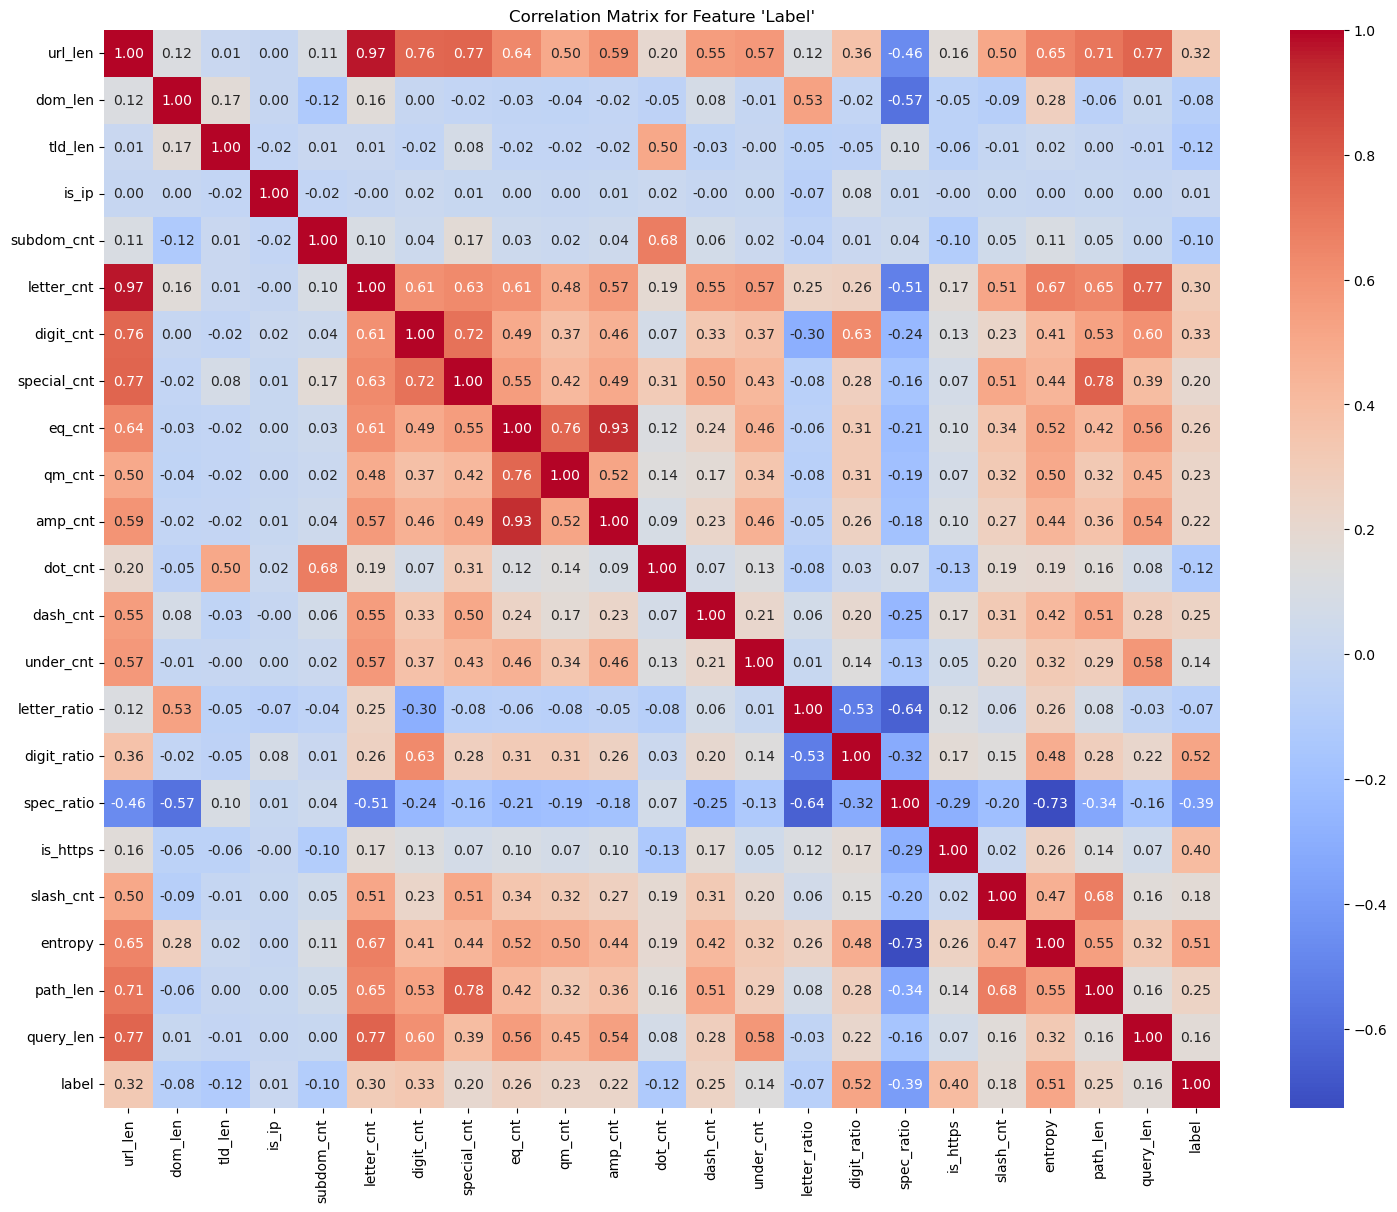

In [35]:
# Plot correlation heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(df_filter.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix for Feature 'Label'")
plt.show()

- Use Random forest to visualise important features and compare with correlation.

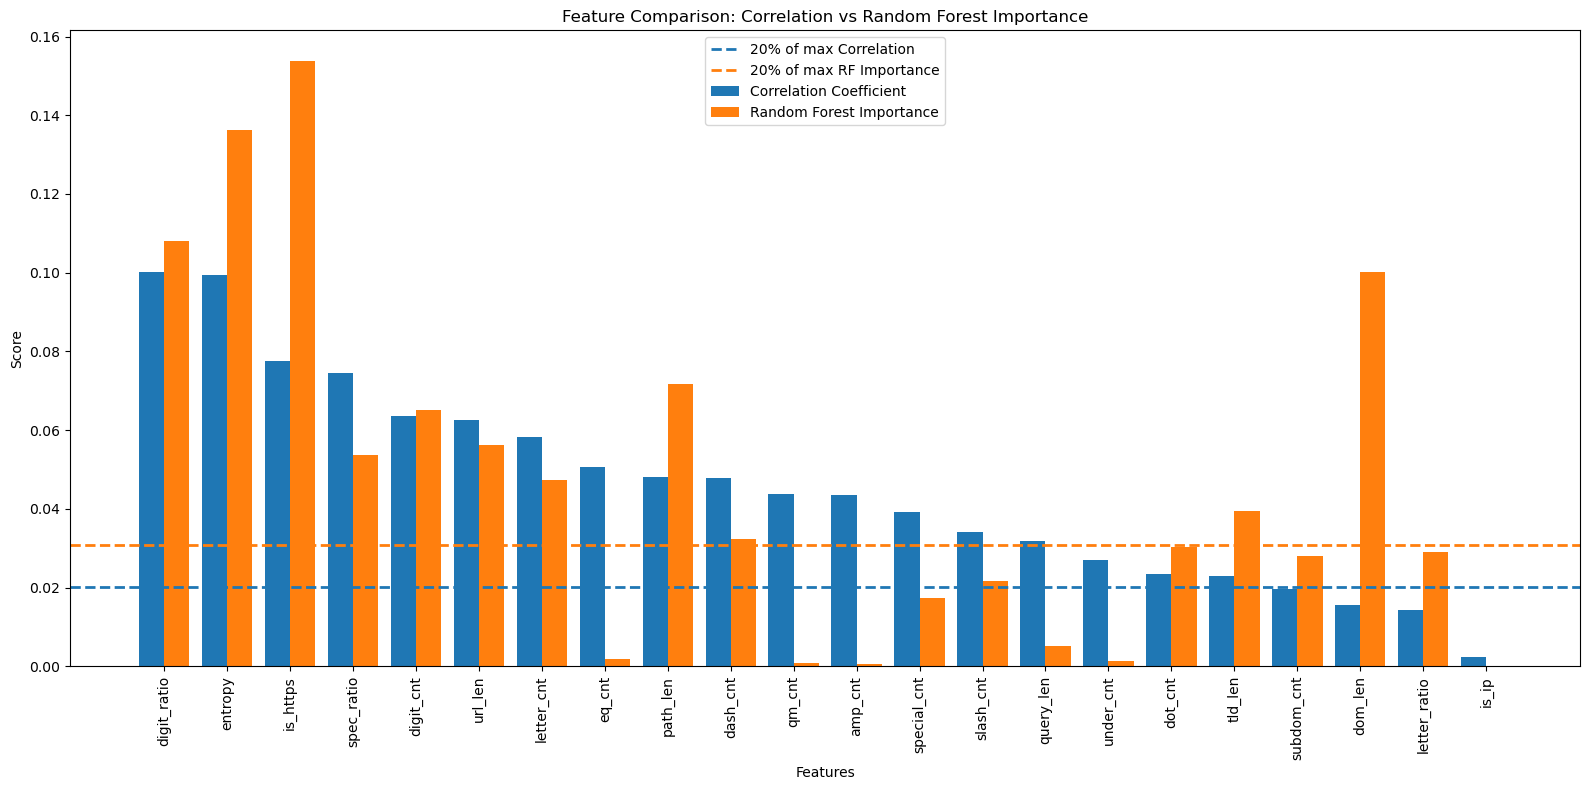

In [36]:
# Remove target itself from correlation list
correlations_without_label = correlations.drop('label')

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Feature': correlations_without_label.index,
    'Correlation_Normalised': correlations_without_label.values / correlations_without_label.sum(),
    'RF_Importance': rf_importance.reindex(correlations_without_label.index).fillna(0).values
})

# Plot
plt.figure(figsize=(16,8))
bar_width = 0.4
indices = np.arange(len(comparison_df))

# Bar graph
plt.bar(indices - bar_width/2, comparison_df['Correlation_Normalised'], width=bar_width, label='Correlation Coefficient')
plt.bar(indices + bar_width/2, comparison_df['RF_Importance'], width=bar_width, label='Random Forest Importance')

# Dotted horizontal line (20% of maximum feature importance)
threshold_co = comparison_df['Correlation_Normalised'].max() * 0.2
threshold_rf = comparison_df['RF_Importance'].max() * 0.2

plt.axhline(y=threshold_co, color='C0', linestyle='--', linewidth=2, label='20% of max Correlation')
plt.axhline(y=threshold_rf, color='C1', linestyle='--', linewidth=2, label='20% of max RF Importance')

plt.xticks(indices, comparison_df['Feature'], rotation=90)
plt.xlabel('Features')
plt.ylabel('Score')
plt.title('Feature Comparison: Correlation vs Random Forest Importance')
plt.legend(loc='upper center')
plt.tight_layout()
plt.show()

## 📏 2.1 Length-Based

It was found that

In [37]:
# Length only features
features_len = ['url_len', 'dom_len', 'tld_len', 'path_len', 'query_len']

## 🧮 2.2 Count-Based

For the count only features, boxplot is **NOT suitable** because of high zero-inflation. _Majority of observations are clustered at 0, with sparce positive outliers_. Hence the interquartile range (IQR) of some boxplots can be difficult to read, because they are as thin as a line with very broad whiskers.

Therefore, the following analysis steps were carried out:
- Stripplot — Replaces boxplot to see raw spread
- Kernel Density Estimator (KDE) — Distribution shape per class (log data)
- Binary Indicator — Convert data to binary to reveal interesting chracteristics

In [38]:
# Count only features
features_cnt = ['letter_cnt', 'digit_cnt', 'special_cnt', 'eq_cnt', 'qm_cnt', 'amp_cnt',
                  'dot_cnt', 'dash_cnt', 'under_cnt', 'slash_cnt', 'subdom_cnt']

**1. Using Stripplot**

We see that there are 3 main features that have a broad and distinguishable spread: **`letter_cnt`**, **`digit_cnt`** and **`special_cnt`**, which are heavily skewed right. Meanwhile, the other features range from having _subtle_ distinguishble spread to _none_ at all. Futher investigation is necessary.

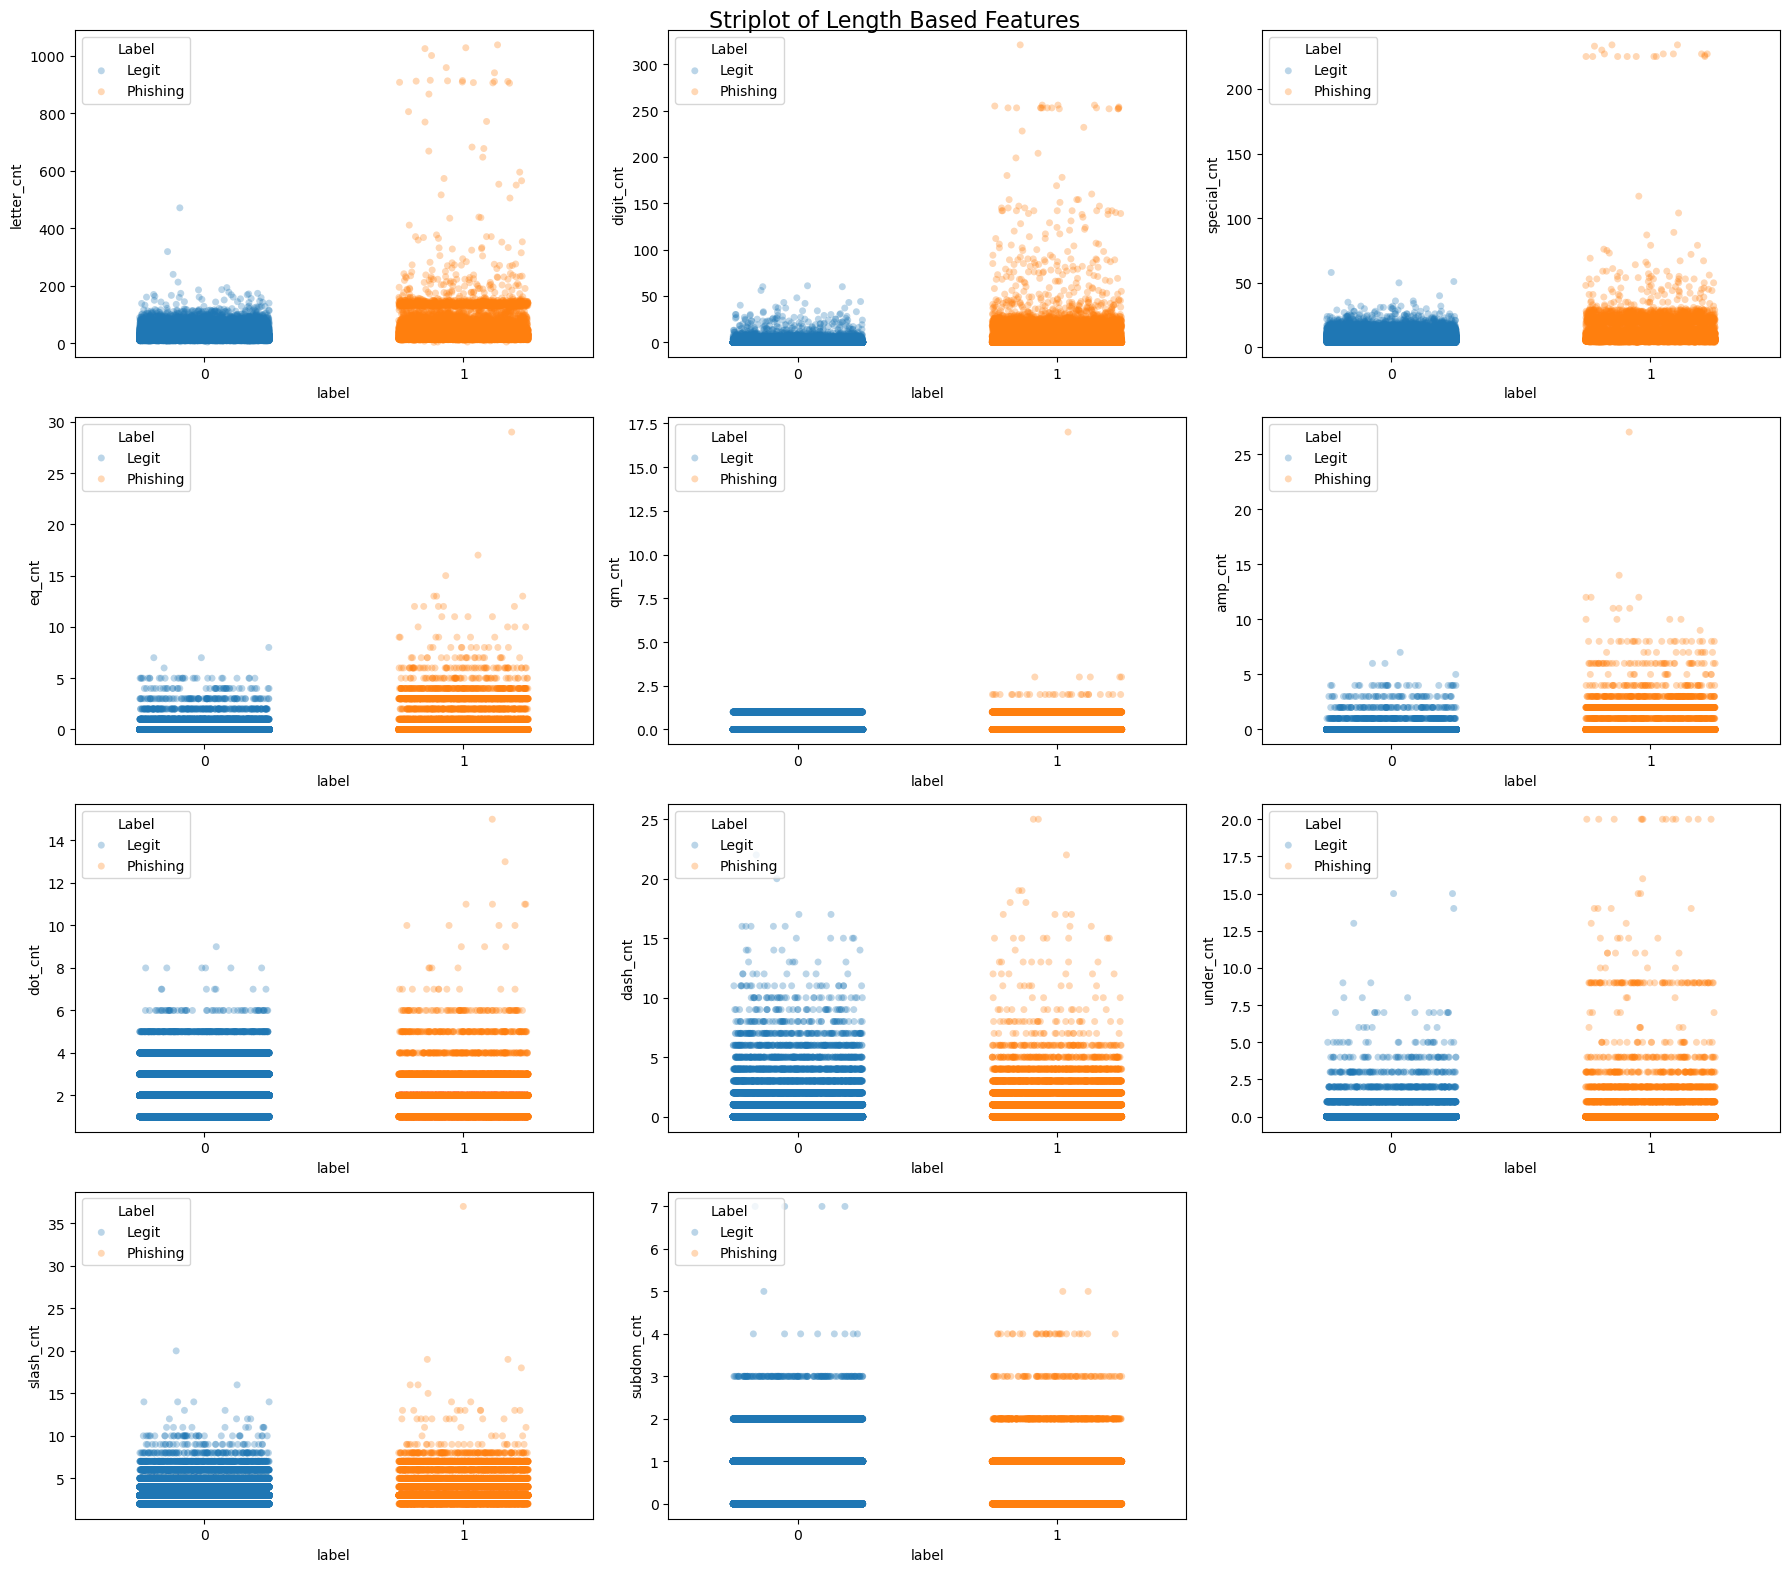

In [39]:
# Rough Distribution using Stripplot
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten() # helps looping

# Plotting in a loop
for i, col in enumerate(features_cnt):
  sns.stripplot(data=df_filter, x='label', y=col, ax=axes[i], jitter=0.25, hue='label', alpha=0.3)
  axes[i].legend(title='Label', labels=["Legit", "Phishing"], loc='upper left')

# Hide the last empty subplot
axes[len(features_cnt)].set_visible(False)

fig.suptitle('Striplot of Length Based Features', fontsize=16)
plt.tight_layout()
plt.show()

**2. Using Kernel Density Estimate (KDE)**

Since the Stripplot does not reveal much about the underlying distribution, use KDE with **log-transformed data**. Some of the reason to use KDE are:
  - Data is heavility zero-centered, making standard histogram hard to interpret.
  - Capture distribution nuance by producing smooth curve rather than jagged histogram.
  - Accurately portray overall spread and shape since is normalised distribution function.

We see that the 3 main features discussed previously indeed show obvious and distinguishable distributions, that is phishing URLs are largely shifted to the right compard to the legitimate URLs. Meanwhile, **`dash_cnt`** and **`slash_cnt`** phishing URLs have slightly higher densities to the right. However, all the other features: **`eq_cnt`**, **`qm_cnt`**, **`amp_cnt`**, **`eq_cnt`**, **`dot_cnt`**, **`under_cnt`** and **`subdomain_cnt`** have identical distribution shapes for both phishing and legitimate URLs, albeit with slightly different variances. Therefore, another method of analysis is required.

> Note that natural logarithm transformation $\ln(x+1)$ was applied to each feature's value to make the distribution's shape more obvious.

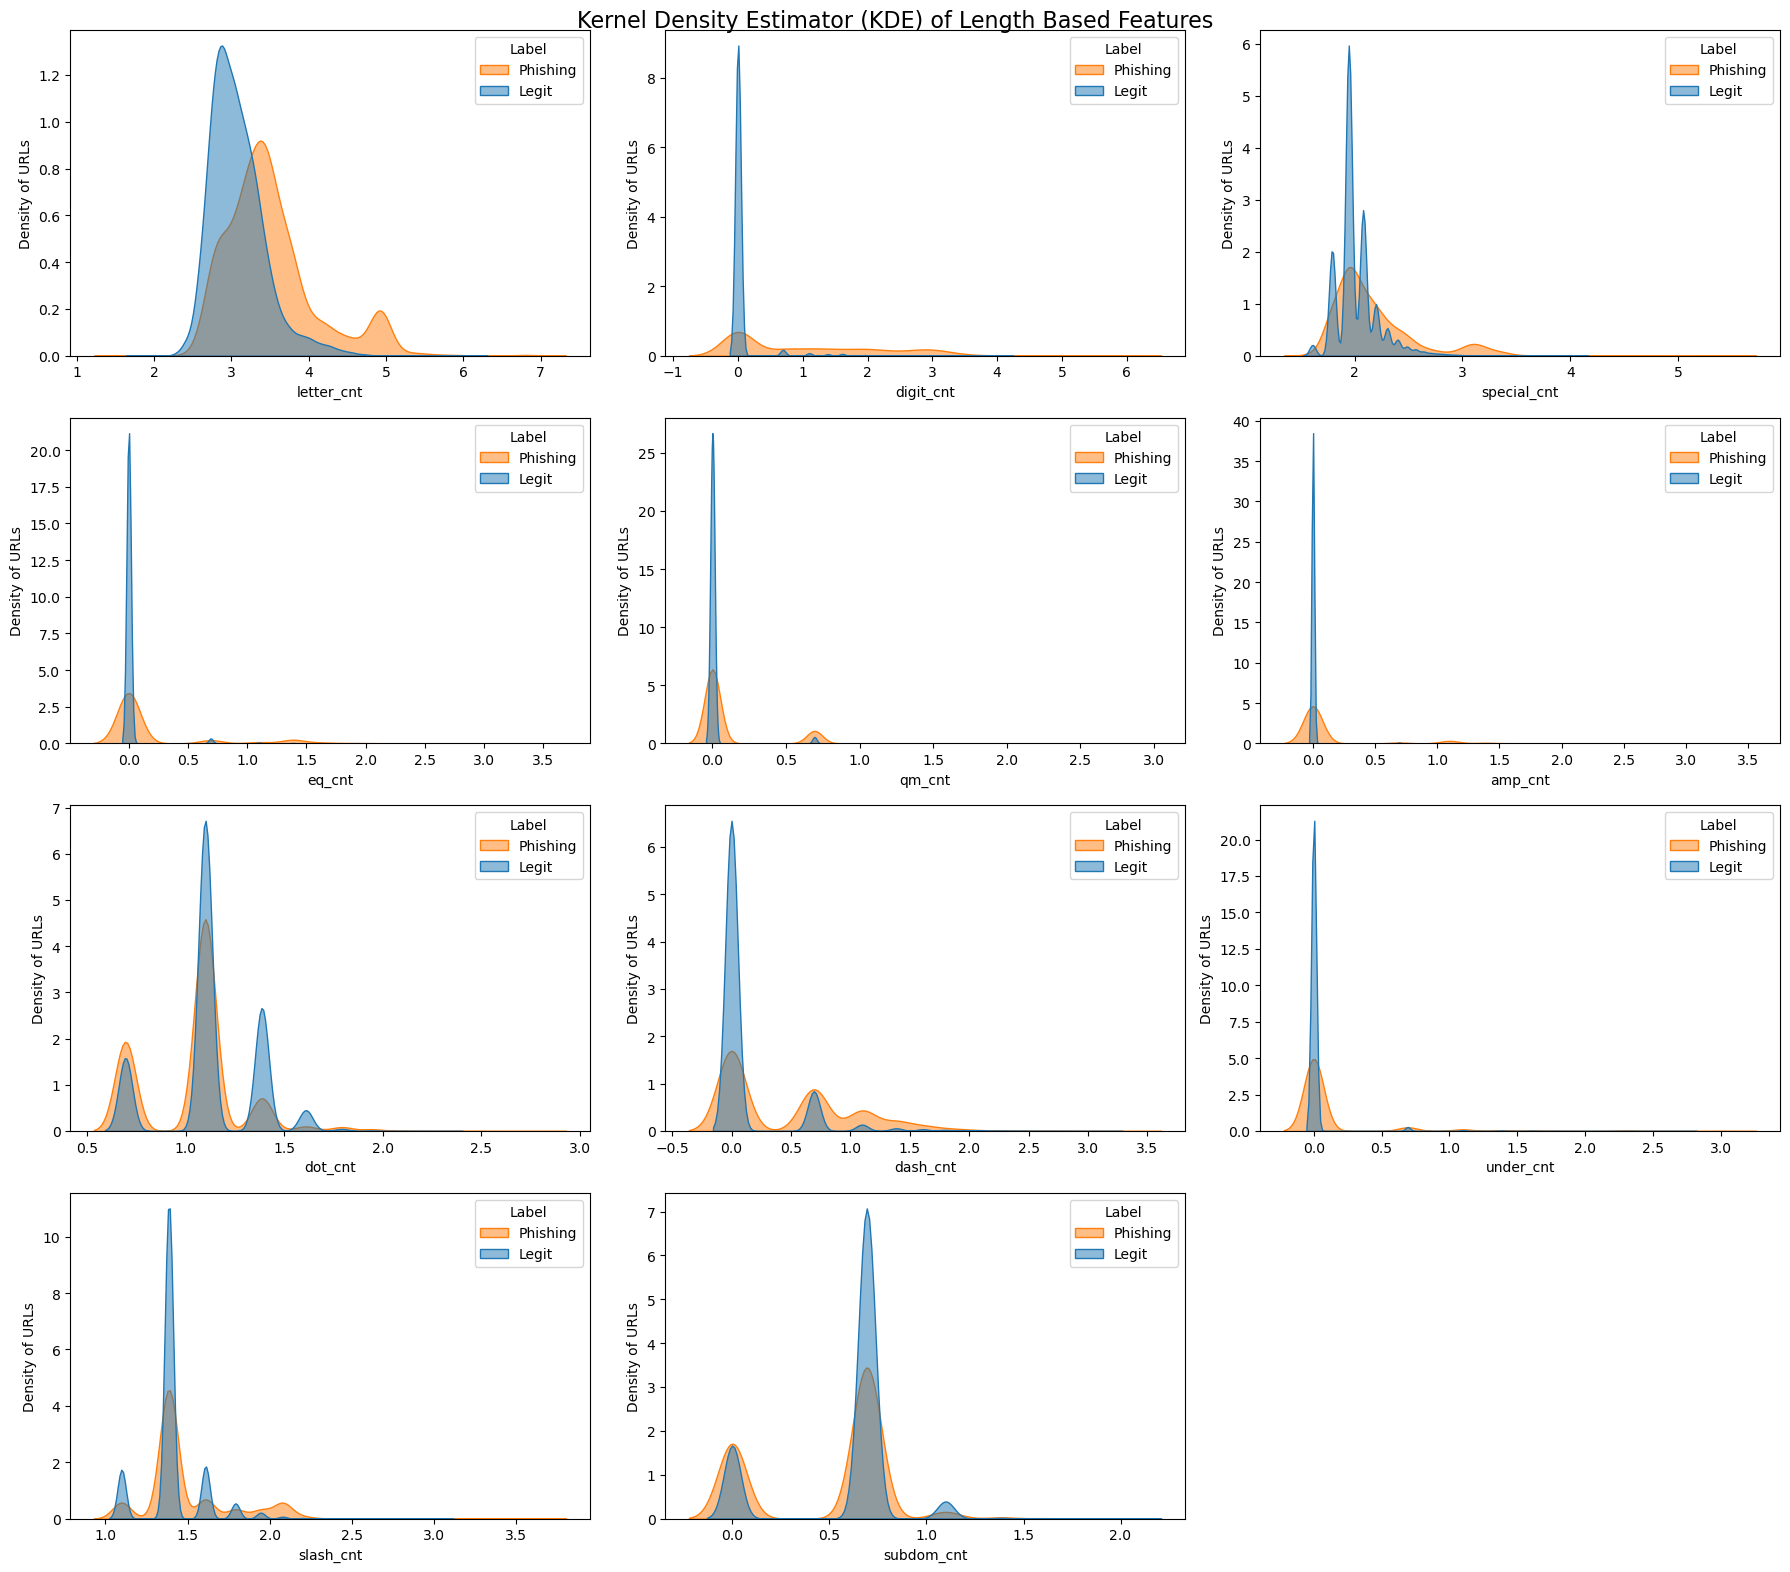

In [40]:
# KDE plot
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten() # helps looping

# Plotting in a loop
for i, col in enumerate(features_cnt):
  log_data = np.log1p(df_filter[col]) # log transform of data
  sns.kdeplot(x=log_data, hue=df_filter['label'], ax=axes[i], fill=True,
              alpha=0.5, common_norm=False, warn_singular=False, bw_adjust=1.5)
  axes[i].legend(title='Label', labels=["Phishing", "Legit"], loc='upper right')
  axes[i].set_ylabel('Density of URLs') 

# Hide the last empty subplot
axes[len(features_cnt)].set_visible(False)

fig.suptitle('Kernel Density Estimator (KDE) of Length Based Features', fontsize=16)
plt.tight_layout()
plt.show()

**3. Count-Threshold Based Analysis**

Examines how the proportions of URLs  changes as  **feature counts exceed increasing thresholds** (e.g. =0, >0, >1, >2 and so on). This approach is more suitable to obtain a better visualisation because majority of raw counts in this dataset are zero (=0) and very few are larger than zero (>0), making it hard to see the underlying trends. 

 The two previous features, **`dash_cnt`** and **`slash_cnt`** now show a clear picture _when increasing their count_, the proportion of phishing URLs is generally larger compared to the legitimate URLs. Meanwhile, other features such as **`eq_cnt`**,**`qm_cnt`**, **`amp_cnt`** and **`under_cnt`** also show the exact same trends. However, analysing **`dot_cnt`** we notice that as the vount increases, proportion of legitimate URLs is actually larger than phishing. Finally, **`subdom_cnt`** does not show any particular bias or trend towards phishing or legitimate.

 > Notably, **`qm_cnt`** seems to only have a single threshold (>0), with the rest (>1, >2, etc) being zero. This makes sense because there can only be one question mark `?` in URL since it denotes a query.

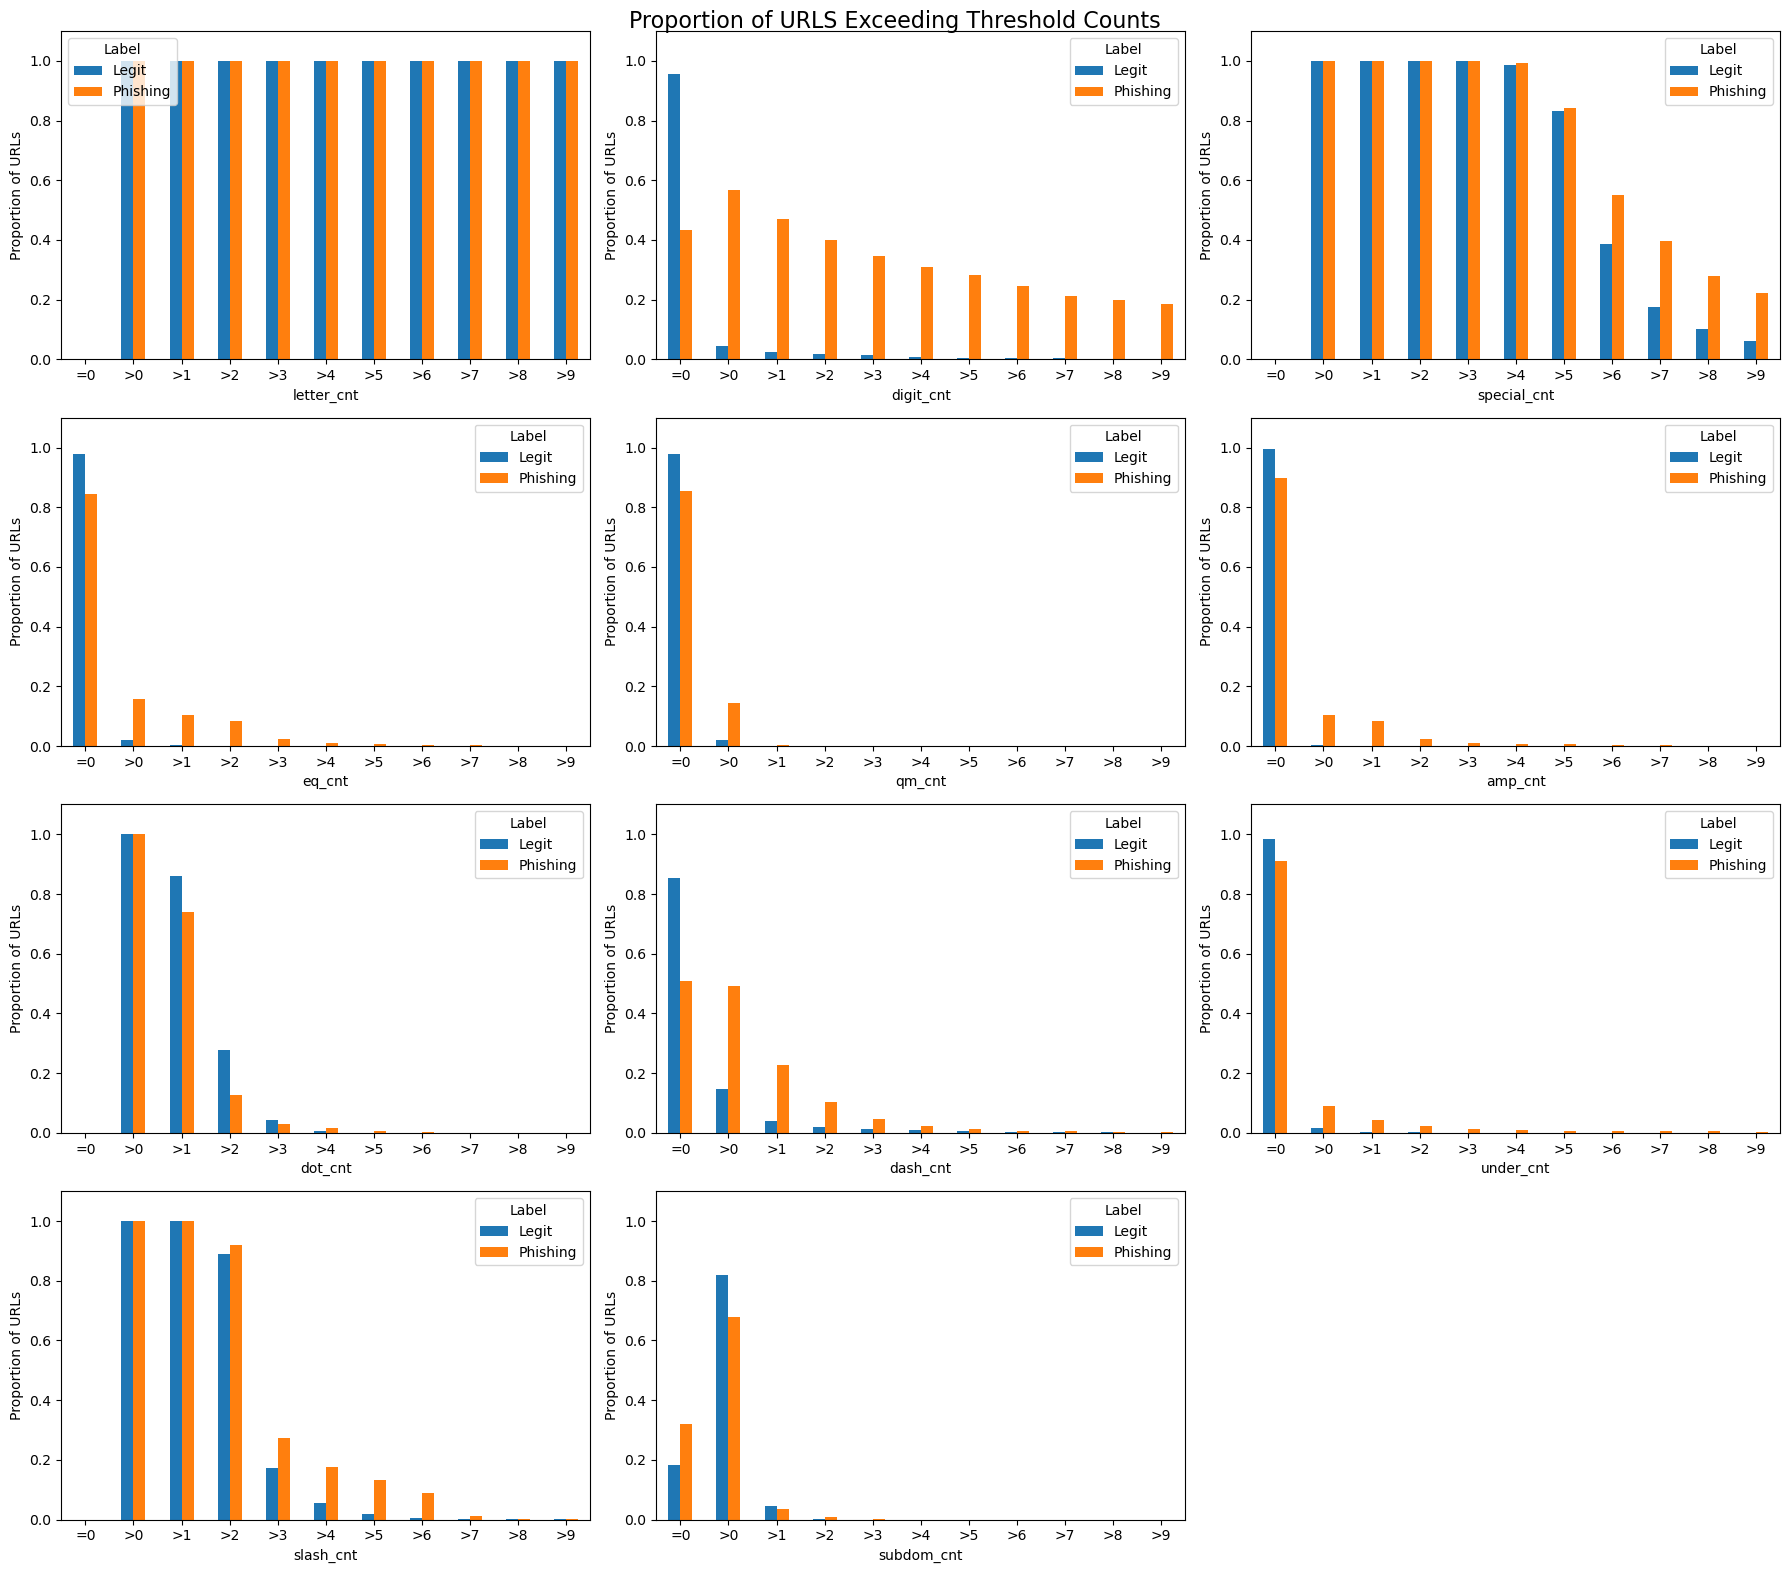

In [49]:
# Bar plot
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

thresholds = range(10)  # 0-7

# Plot loop
for i, col in enumerate(features_cnt):
    # Build dataframe directly
    bar_df = pd.DataFrame()
    # =0 case
    bar_df['=0'] = (df_filter[col] == 0).groupby(df_filter['label']).mean()
    # thresholds
    for t in thresholds: 
        bar_df[f'>{t}'] = (df_filter[col] > t).groupby(df_filter['label']).mean()
    bar_df = bar_df.T

    # Plot
    bar_df.plot(kind='bar', ax=axes[i])
    axes[i].set_ylim(0, 1.1)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Proportion of URLs")
    axes[i].legend(title='Label', labels=["Legit", "Phishing"])
    axes[i].tick_params(axis='x', rotation=0)

# Hide unused subplot
axes[len(features_cnt)].set_visible(False)

# Title + layout
fig.suptitle("Proportion of URLS Exceeding Threshold Counts", fontsize=16)
plt.tight_layout()
plt.show()

**1. `letter_cnt`**

From KDE plot, legitimate URLs have unimodal distribution peaking at approximately 3 (~19.09 counts), while phishing URLs is bimodal with peaks at approximately 3.5 (~32.12 counts) and 5 (~147.41 counts). Distribution for phishing is also more heavily right-skewed compared to legitimate. Overall, phishing URLs have longer letter counts than legitimate URLs.


**2. `digit_cnt`**

From KDE plot, both legitimate and phishing URLs are unimodal distributions, peaking at 0 (~0 counts). However, distribution for phishing have a much broader right-skewed tail. Overall, phishing URLS have highier digit count compared to legitimate URLs.


**3. `special_cnt`**

From KDE plot, legitimate URLs have unimodal distribution peaking at approximately 2 (~6.39 counts). Meanwhile, phishing URLs is bimodal with peaks at approximately 2 (~6.39 counts) and 3.1 (~21.20 counts). Distribution for phishing is also more heavily right-skewed compared to legitimate. Overall, phishing URLs have more special characters compared to legitimate URLs.

**4. `eq_cnt`**

From the bar plot, almost 100% of legitimate URLs and approximately 80% of phishing URLs have 0 counts (i.e. at threshold =0). However, beyond zero (>0, >1, etc.), phishing consistently show higher proportions compared to legitimate. This makes sense because (`=`) are commonly used in query strings to structure parameters, which are used by attackers. Overall, URLs containing equals sign character (`=`) is a good indicator of phishing URLs. 


**5. `qm_cnt`**

From the bar plot, almost 100% of legitimate URLs and approximately 80% of phishing URLs have 0 counts (i.e. at threshold =0). Interestingly, comparing the proportion of zero counts (=0) of question mark character (`?`) with equals sign character (`=`), we find that they are identical. This makes sense because (`?`) start a URL query while (`=`) assigns variable to the query, hence they always comes in pairs. Another interesting finding is that, there is never more than a single (`?`) in this dataset. Overall, URLs containing question marks (`?`) is a strong indicator of phishing.


**6. `amp_cnt`**

From the bar plot, almost 100% of legitimate URLs and approximately 90% of phishing URLs have 0 counts (i.e. at threshold =0). However, beyond zero (>0, >1, etc.), phishing consistenly show higher proportions compared to legitimate. This makes sense because the role of ampersand character (`&`) is to seperate multiple key-value pairs within same query string (`?`) as discussed previously. Overall, URLs containing ampersand sign character (`=&) is a good indicator of phishing URLs. 

**7. `dot_cnt`**

From the bar plot, it was observed that the proportion of legitimate URLs tend to be larger compared to phishing URLs as the number of dot characters (`.`) increase. This overlap makes it challenging to reliably distinguish phishing URLs from legitimate ones.


**8. `dash_cnt`**

From the bar plot, it was observed that the proportion of phishing URLs with more-than-one (i.e. at threshold >0, >1, etc.) dash character (`-`)  is much higher compared to legitimate URLs. This strongly suggests that URLs that have dashes (`-`) are likely phishing.


**9. `under_cnt`**

From the bar plot, almost 100% of legitimate URLs and approximately 90% of phishing URLs have 0 counts (i.e. at threshold =0). However, beyond zero (>0, >1, etc.), phishing consistently show higher proportions compared to legitimate. This makes sense because underscore character (`_`) is not commonly used in website names. Overall, URLs containing underscore character (`_`) is a strong indicator of phishing.


**10. `slash_cnt`**

From the bar plot, it was observed that the proportion of phishing URLs with more-than-four (i.e. at thresholds >3, >4, etc.) slash character (`/`)  is higher compared to legitimate URLs. This strongly suggests that URLs with large number of slashes (`/`) are likely to be phishing.


**11. `subdom_cnt`**

From the bar plot, it was observes that URLs with zero subdomains (e.g. `.www`) have higher proportion to be phishing. Meanwhile, URLs with a single subdomain have higher proportion to be legitimate. However, there does not seem to be a clear trend the distribution helps distinguish between legitimate and phishing. Overall, the number of subdomains alone is probably not a strong feature to indicate phishing.  

## ➗ 2.3 Ratio-Based

In [42]:
# Length only features
features_ratio = ['letter_ratio', 'digit_ratio', 'spec_ratio']

## ⭕ 2.4 Structural / Binary

**1. Proportions of `is_ip` and `is_https`**

Analysing the propotions of URLs which have ip addresses in their domain name, and also https as their application level protocol.

In [43]:
# Binary only features
features_binary = ['is_ip', 'is_https']

for col in features_binary:
    print(f"\n{col} distribution:")
    print(df_filter[col].value_counts(normalize=True))


is_ip distribution:
is_ip
0    0.999887
1    0.000113
Name: proportion, dtype: float64

is_https distribution:
is_https
0    0.569257
1    0.430743
Name: proportion, dtype: float64


**2. Proportions Considering Legitimate and Phishing**

Comparing the proportions of legitimate and phishing URLs of the two previous features.


is_ip vs label:


label,0,1
is_ip,,
0,0.856073,0.143927
1,0.461538,0.538462



is_https vs label:


label,0,1
is_https,,
0,0.978322,0.021678
1,0.694409,0.305591


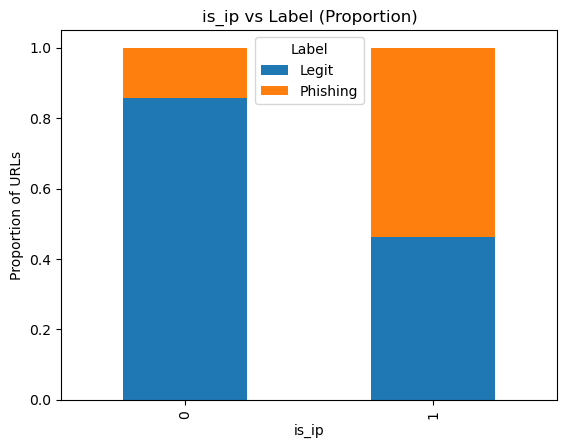

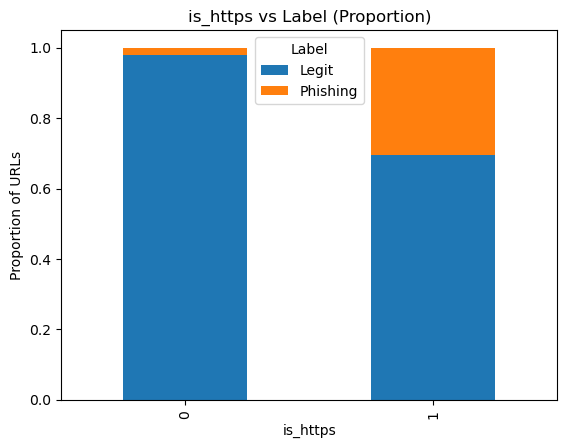

In [44]:
# Method: Groupby + Normalize
for col in features_binary:
    print(f"\n{col} vs label:")
    display(pd.crosstab(df_filter[col], df_filter['label'], normalize='index'))
    
    
# Percentage Bar Plot
for col in features_binary:
    temp = pd.crosstab(df_filter[col], df_filter['label'], normalize='index')
    temp.plot(kind='bar', stacked=True)
    plt.title(f"{col} vs Label (Proportion)")
    plt.ylabel("Proportion of URLs")
    plt.xlabel(col)
    plt.legend(title="Label", labels=["Legit", "Phishing"], loc='upper center')
    plt.show()

**`is_ip`**

URLs containing IP addresses exhibit a higher proportion of phishing cases, suggesting that attackers often bypass domain registration to reduce traceability and detection.

**`is_https`**

The presence of HTTPS does not strongly differentiate phishing from legitimate URLs, as phishing sites increasingly adopt HTTPS to mimic secure and trustworthy websites.

## 🌡️ 2.5. Shanon Entropy

In [45]:
# Entropy only features
features_entropy = ['entropy']


### Theory

Given a discrete random variable $X$ over an alphabet $\mathcal{A}$ with probability mass function $P(X=x_i)=p_i$, the **Shanon entropy** is:
$$
H(X)=-\sum_{i=1}^n p_i\log_2p_i
$$

For a string $s$ of length $N$ over alphabet $\mathcal{A}$, the formula for probability $p_i$ of seeing character $c_i$ is:
$$
p_i=\frac{\mathrm{count}(c_i,s)}{N},\qquad \forall c_i\in\mathcal{A}
$$

Therefore, the full formula for Shanon entropy applied to a string is:
$$
H(s)=-\sum_{c_i\in\mathcal{A}}\frac{\mathrm{count}(c_i,s)}{N}\cdot \log_2\left(\frac{\mathrm{count}(c_i,s)}{N}\right)
$$

Invariant rule:
$$
0\leq H(s)\leq \log_2\left|\mathcal{A}\right|
$$

> Note that these are **empirical frequencies**, the string's character distribution is used as the probability model. Meaning, this is the most fundamental form of entropy that solely depends on the number of occurrences of a character within a particular string, it does NOT use the known probability of a character appearing in English langauge (i.e. Cross Entropy).

---

# IMPORTANT AI

The Architecture: Two Feature Matrices

You will start with your base dataframe containing the engineered binary flags (has_eq, has_amp, etc.) and the raw counts (letter_cnt, subdom_cnt, etc.). From there, split your pipeline:
Pipeline A: The Tree Space (X_tree)

(For XGBoost, Random Forest, LightGBM)

    Transformations: None.

    Mechanism: Feed the raw counts and binary flags directly.

    Trade-off: This maintains perfect interpretability. When you generate feature importance scores or SHAP values later, "number of letters > 50" is much easier to explain to stakeholders than "log(number of letters) > 3.9".

Pipeline B: The Gradient Space (X_linear)

(For Logistic Regression, SVM, Neural Networks)

    Transformations: Log(1 + x) on high-variance counts AND feature scaling.

    Mechanism: First, apply the log transform to features like letter_cnt, digit_cnt, and special_cnt to compress the outliers and stabilize the variance.

    The Missing Step (Scaling): For gradient models, log-transforming is not enough. You must also apply a StandardScaler or MinMaxScaler to the entire matrix. Gradient descent assumes all features exist on roughly the same scale. If your binary flags are [0, 1] but your log-transformed letter counts are [0, 6], the model will still incorrectly prioritize the larger numbers.